# Convolutional Neural Networks

We train a small CNN on local handwritten digits, inspect every tensor shape,
and use a forward hook to view learned feature maps. The notebook is deliberately
small enough to run on a laptop CPU.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

SEED = 26514
np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(1)
digits = pd.read_csv('SklearnDigits.csv')
X = digits.drop(columns='target').to_numpy(np.float32).reshape(-1, 1, 8, 8) / 16
y = digits.target.to_numpy(np.int64)
train_i, rest_i = train_test_split(
    np.arange(len(y)), train_size=1200, random_state=SEED, stratify=y
)
valid_i, test_i = train_test_split(
    rest_i, train_size=300, random_state=SEED + 1, stratify=y[rest_i]
)

def make_loader(index, shuffle):
    dataset = TensorDataset(torch.from_numpy(X[index]), torch.from_numpy(y[index]))
    return DataLoader(
        dataset, batch_size=64, shuffle=shuffle,
        generator=torch.Generator().manual_seed(SEED)
    )

train_loader = make_loader(train_i, True)
valid_loader = make_loader(valid_i, False)
test_loader = make_loader(test_i, False)
next(iter(train_loader))[0].shape

torch.Size([64, 1, 8, 8])

## Define the architecture and verify its shapes

In [2]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.head = nn.Linear(16 * 4 * 4, 10)

    def forward(self, x, return_features=False):
        h1 = torch.relu(self.bn1(self.conv1(x)))
        h2 = torch.relu(self.bn2(self.conv2(self.pool(h1))))
        logits = self.head(h2.flatten(1))
        return (logits, h1, h2) if return_features else logits

model = SmallCNN()
xb, yb = next(iter(train_loader))
logits, h1, h2 = model(xb, return_features=True)
print('input:', tuple(xb.shape))
print('first feature maps:', tuple(h1.shape))
print('second feature maps:', tuple(h2.shape))
print('logits:', tuple(logits.shape))
print('parameters:', sum(p.numel() for p in model.parameters()))

input: (64, 1, 8, 8)
first feature maps: (64, 8, 8, 8)
second feature maps: (64, 16, 4, 4)
logits: (64, 10)
parameters: 3866


## Batch normalization behaves differently in training and evaluation

In training mode, batch normalization uses the current minibatch and updates
running averages. In evaluation mode, it uses those stored averages, so one
prediction does not depend on the other examples in the evaluation batch.

In [3]:
# Keep the first image fixed, but change the other images in its batch.
anchor = xb[:1]
real_companions = xb[1:16]
dark_companions = torch.zeros_like(real_companions)
batch_real = torch.cat([anchor, real_companions], dim=0)
batch_dark = torch.cat([anchor, dark_companions], dim=0)

model.bn1.reset_running_stats()
running_mean_before = model.bn1.running_mean.clone()

model.train()  # BatchNorm: current minibatch; running averages are updated.
with torch.no_grad():
    anchor_train_real = model.bn1(model.conv1(batch_real))[0]
    anchor_train_dark = model.bn1(model.conv1(batch_dark))[0]
running_mean_after = model.bn1.running_mean.clone()

model.eval()  # BatchNorm: stored running averages; no batch-dependent update.
with torch.no_grad():
    anchor_eval_real = model.bn1(model.conv1(batch_real))[0]
    anchor_eval_dark = model.bn1(model.conv1(batch_dark))[0]

train_difference = (anchor_train_real - anchor_train_dark).abs().max().item()
eval_difference = (anchor_eval_real - anchor_eval_dark).abs().max().item()
running_update = (running_mean_after - running_mean_before).abs().max().item()

print(f'training mode: same image, different companions -> max difference {train_difference:.4f}')
print(f'evaluation mode: same image, different companions -> max difference {eval_difference:.4f}')
print(f'largest running-mean update during training mode: {running_update:.4f}')
assert train_difference > 1e-3
assert eval_difference < 1e-6
assert running_update > 0

# The training loop below sets the appropriate mode explicitly each time.
model.train()

training mode: same image, different companions -> max difference 8.6005
evaluation mode: same image, different companions -> max difference 0.0000
largest running-mean update during training mode: 0.0631


SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Linear(in_features=256, out_features=10, bias=True)
)

## Train with the Lecture 12 loop

In [4]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(batches):
    model.eval()  # BatchNorm uses stored running statistics.
    correct = total = 0
    for xb, yb in batches:
        correct += int((model(xb).argmax(1) == yb).sum())
        total += len(yb)
    return correct / total

history = []
for epoch in range(1, 16):
    model.train()  # BatchNorm uses minibatch statistics and updates its averages.
    correct = total = 0
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        correct += int((logits.argmax(1) == yb).sum())
        total += len(yb)
    history.append((epoch, correct / total, evaluate(valid_loader)))

history = pd.DataFrame(history, columns=['epoch', 'training_accuracy', 'validation_accuracy'])
print(history.tail())
print('test accuracy:', evaluate(test_loader))
assert evaluate(test_loader) > 0.94

    epoch  training_accuracy  validation_accuracy
10     11           0.999167             0.986667
11     12           1.000000             0.980000
12     13           1.000000             0.980000
13     14           1.000000             0.983333
14     15           1.000000             0.983333
test accuracy: 0.9865319865319865


## Inspect learned feature maps

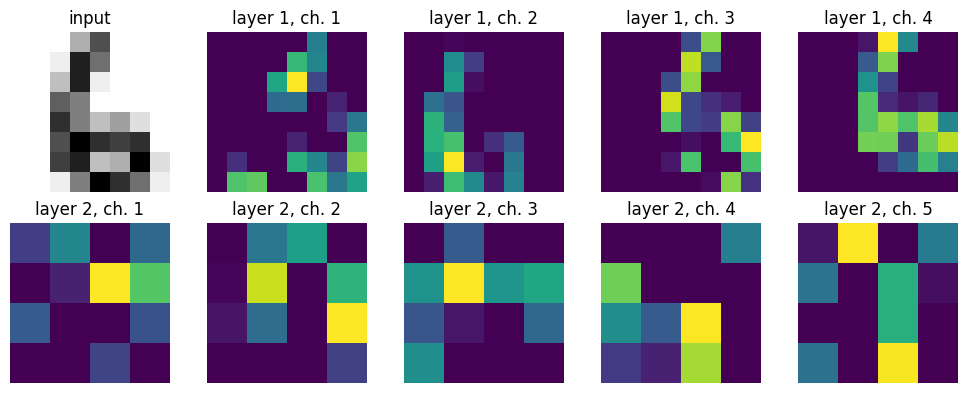

In [5]:
model.eval()
example = torch.from_numpy(X[test_i[:1]])
with torch.no_grad():
    _, first_maps, second_maps = model(example, return_features=True)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes[0, 0].imshow(example[0, 0], cmap='gray_r')
axes[0, 0].set_title('input')
for j in range(1, 5):
    axes[0, j].imshow(first_maps[0, j - 1], cmap='viridis')
    axes[0, j].set_title(f'layer 1, ch. {j}')
for j in range(5):
    axes[1, j].imshow(second_maps[0, j], cmap='viridis')
    axes[1, j].set_title(f'layer 2, ch. {j + 1}')
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout();

A bright location means the channel responds strongly there. Each
panel has its own color scale, so compare spatial patterns, not amplitudes across
channels. A channel need not correspond to one human-named concept.